# Reto Parcial 1 - REHAB: Clasificacion de movimientos de rehabilitacion

**Equipo:** Angel Lugo, Jose Pablo, Juan Pablo

**Dataset:** REHAB - Rehab_exercise (16 movimientos de entrenamiento de rehabilitacion post-ACV)
Fuente: Lv et al. (2026), *Scientific Data* 13:1136. https://doi.org/10.57760/sciencedb.37018


In [1]:
!git clone https://github.com/AngelDavid8705/REHAB-RETO.git
%cd REHAB-RETO/notebooks

fatal: destination path 'REHAB-RETO' already exists and is not an empty directory.
/content/REHAB-RETO/notebooks


## 1. Setup

In [2]:
import sys, os
sys.path.append('/content/REHAB-RETO/src')

import numpy as np
import matplotlib.pyplot as plt
from data_loader import build_dataset, MOVEMENT_NAMES

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Cargar el dataset con la carpeta "d02_processed_data"

In [3]:
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = "/content/drive/MyDrive/Reto_rehab/REHAB/Rehab_exercise/d02_processed_data"

X, y, meta = build_dataset(DATA_DIR, incluir_mov14_parcial=False)
print("\nForma final:", X.shape, y.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset consolidado: X=(4257, 880, 12), y=(4257,)
Clases presentes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15]
  mov 00 (bobath handshake): 232 muestras
  mov 01 (bobath flexion/extension): 212 muestras
  mov 02 (bobath forward flexion/extension): 267 muestras
  mov 03 (bobath anterior/posterior rotation): 250 muestras
  mov 04 (elbow flexion and wrist compression): 287 muestras
  mov 05 (wrist flexion and extension): 293 muestras
  mov 06 (finger-to-finger training): 260 muestras
  mov 07 (ball gripping): 385 muestras
  mov 08 (shoulder joint internal and external rotation): 299 muestras
  mov 09 (breast expansion): 307 muestras
  mov 10 (flexion-pressure rotation forward and backward): 311 muestras
  mov 11 (elbow joint flexion and touch): 235 muestras
  mov 12 (shoulder touch training): 293 muestras
  mov 13 (ankle extension & knee internal/externa

## 3. Distribucion de clases

El paper reporta un dataset razonablemente balanceado (212 a 385 muestras por clase). Lo
confirmamos aqui, y vemos donde queda el hueco del movimiento 14 si se excluye.

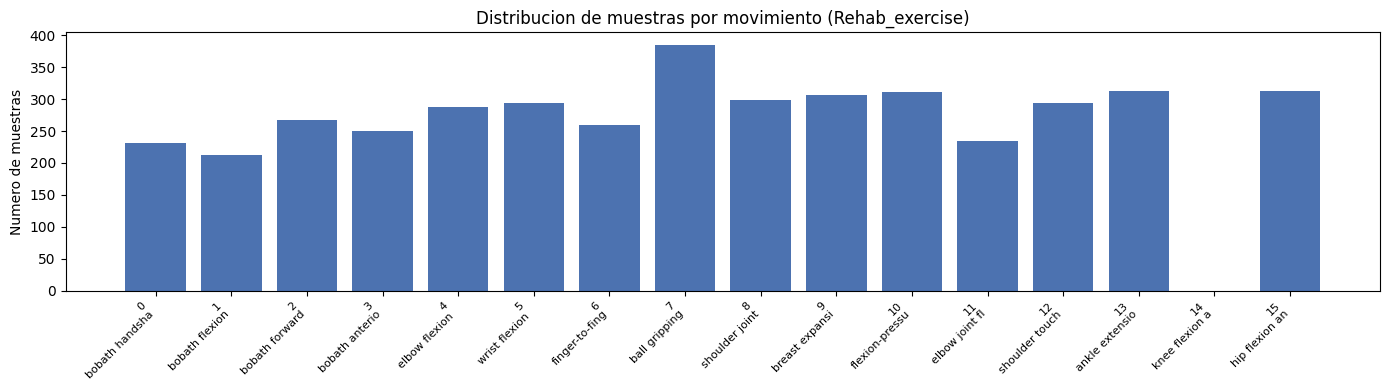

mov 00 - bobath handshake                             :  232 muestras
mov 01 - bobath flexion/extension                     :  212 muestras
mov 02 - bobath forward flexion/extension             :  267 muestras
mov 03 - bobath anterior/posterior rotation           :  250 muestras
mov 04 - elbow flexion and wrist compression          :  287 muestras
mov 05 - wrist flexion and extension                  :  293 muestras
mov 06 - finger-to-finger training                    :  260 muestras
mov 07 - ball gripping                                :  385 muestras
mov 08 - shoulder joint internal and external rotation:  299 muestras
mov 09 - breast expansion                             :  307 muestras
mov 10 - flexion-pressure rotation forward and backward:  311 muestras
mov 11 - elbow joint flexion and touch                :  235 muestras
mov 12 - shoulder touch training                      :  293 muestras
mov 13 - ankle extension & knee internal/external rotation:  313 muestras
mov 14 - knee f

In [4]:
counts = {mov: (y == mov).sum() for mov in range(16)}
labels = [f"{mov}\n{MOVEMENT_NAMES[mov][:14]}" for mov in counts]

plt.figure(figsize=(14, 4))
plt.bar(labels, counts.values(), color="#4C72B0")
plt.ylabel("Numero de muestras")
plt.title("Distribucion de muestras por movimiento (Rehab_exercise)")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

for mov, c in counts.items():
    flag = "  <-- excluido (dato corrupto en la fuente)" if c == 0 else ""
    print(f"mov {mov:02d} - {MOVEMENT_NAMES[mov]:45s}: {c:4d} muestras{flag}")

## 4. Visualizar señales de ejemplo

Cada muestra tiene 880 puntos de tiempo x 12 canales (6 IMU + 6 guante). Grafiquemos los
canales IMU de una muestra por clase para tener una primera intuicion de como se ven las
señales de movimientos distintos.

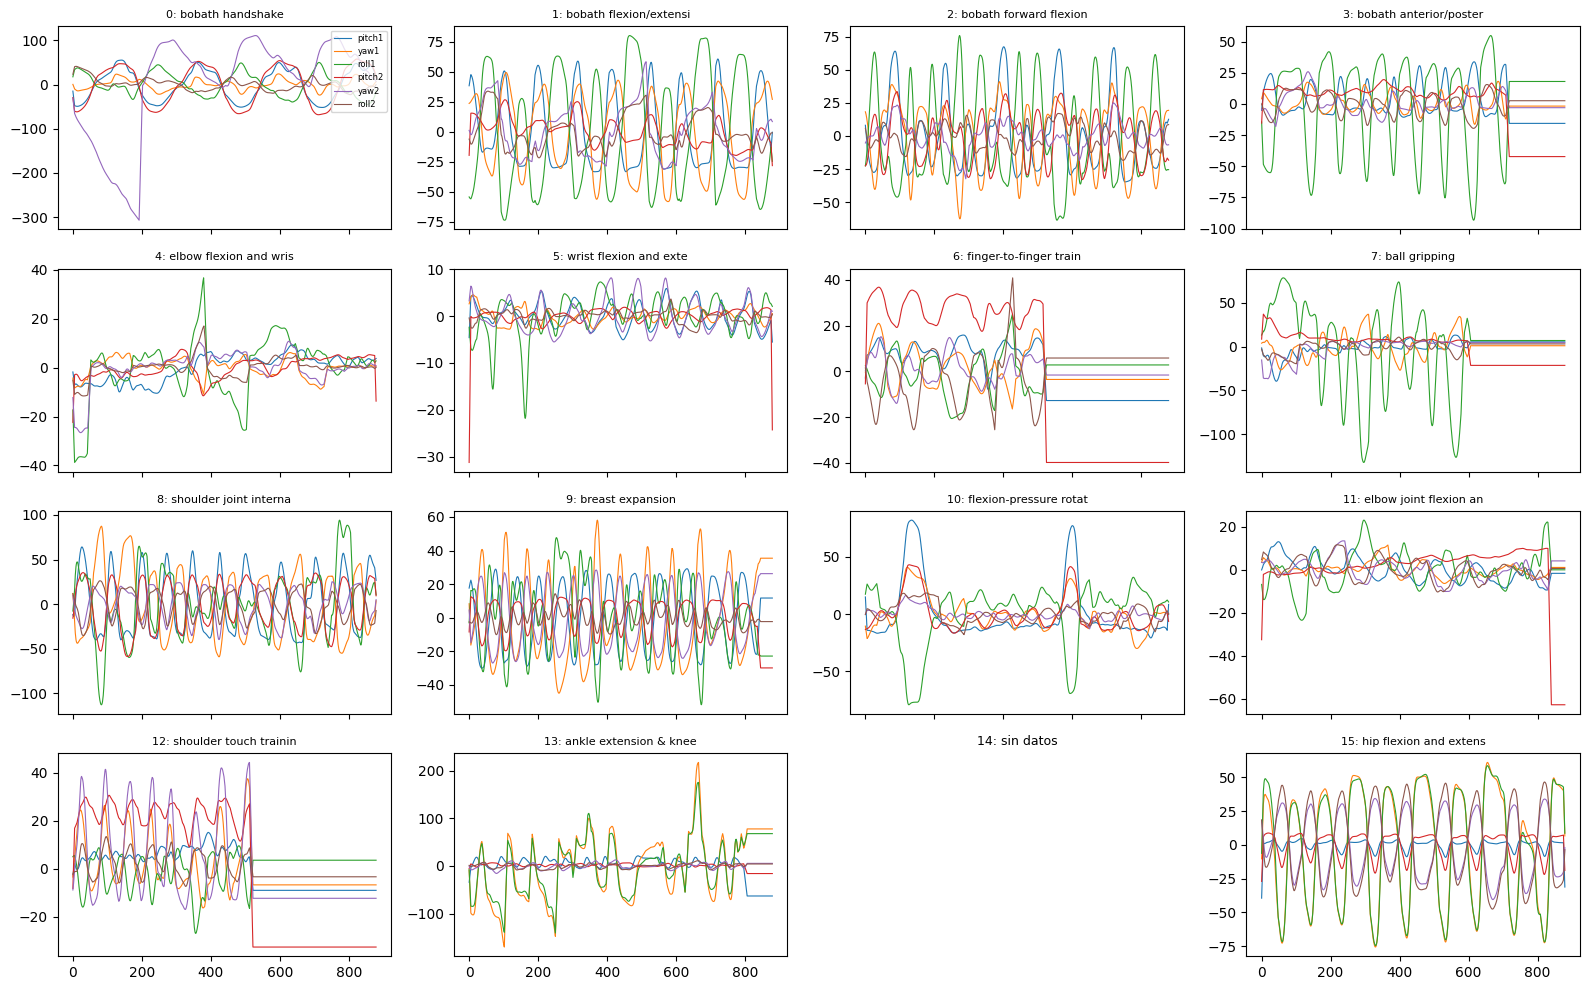

In [5]:
fig, axes = plt.subplots(4, 4, figsize=(16, 10), sharex=True)
imu_channel_names = ["pitch1", "yaw1", "roll1", "pitch2", "yaw2", "roll2"]

for ax, mov in zip(axes.flat, range(16)):
    idx = np.where(y == mov)[0]
    if len(idx) == 0:
        ax.set_title(f"{mov}: sin datos", fontsize=9)
        ax.axis("off")
        continue
    sample = X[idx[0]]
    for c in range(6):
        ax.plot(sample[:, c], linewidth=0.8, label=imu_channel_names[c])
    ax.set_title(f"{mov}: {MOVEMENT_NAMES[mov][:22]}", fontsize=8)

axes.flat[0].legend(fontsize=6, loc="upper right")
plt.tight_layout()
plt.show()

## 5. Chequeos de calidad de datos

Antes de pasar a la etapa de modelado comprobamos:
- Que no haya NaN/Inf en el set principal (sin el movimiento 14 parcial).
- El desbalance real entre clases (razon max/min de muestras).
- El hueco de datos del movimiento 14, para discutirlo en el reporte del equipo.

In [6]:
print("NaN en X:", np.isnan(X).sum())
print("Inf en X:", np.isinf(X).sum())

vals = np.array(list(counts.values()))
vals_validas = vals[vals > 0]
print(f"Muestras por clase -> min={vals_validas.min()}, max={vals_validas.max()}, "
      f"razon max/min={vals_validas.max()/vals_validas.min():.2f}")

print("\nClases con datos:", sorted(set(y.tolist())))
print("Clases SIN datos (excluidas):", [m for m, c in counts.items() if c == 0])

NaN en X: 0
Inf en X: 0
Muestras por clase -> min=212, max=385, razon max/min=1.82

Clases con datos: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15]
Clases SIN datos (excluidas): [14]


## 6. Guardar dataset consolidado

Guardamos `X`, `y` en un solo `.npz` para la carga/consolidacion en la siguiente etapa (modelado).

In [7]:
import os
os.makedirs("../data/processed", exist_ok=True)
np.savez_compressed("../data/processed/rehab_exercise_consolidado.npz", X=X, y=y)
print("Guardado en ../data/processed/rehab_exercise_consolidado.npz")

Guardado en ../data/processed/rehab_exercise_consolidado.npz


In [9]:
!cd /content/REHAB-RETO && git pull

!python /content/REHAB-RETO/src/split_data.py /content/REHAB-RETO/data/processed/rehab_exercise_consolidado.npz

Already up to date.
Total: 4257 muestras

Train: 2979 muestras
  clase 00: 162 (5.4%)
  clase 01: 148 (5.0%)
  clase 02: 187 (6.3%)
  clase 03: 176 (5.9%)
  clase 04: 201 (6.7%)
  clase 05: 205 (6.9%)
  clase 06: 182 (6.1%)
  clase 07: 269 (9.0%)
  clase 08: 209 (7.0%)
  clase 09: 215 (7.2%)
  clase 10: 217 (7.3%)
  clase 11: 165 (5.5%)
  clase 12: 205 (6.9%)
  clase 13: 219 (7.4%)
  clase 15: 219 (7.4%)

Validation: 639 muestras
  clase 00: 35 (5.5%)
  clase 01: 32 (5.0%)
  clase 02: 40 (6.3%)
  clase 03: 37 (5.8%)
  clase 04: 43 (6.7%)
  clase 05: 44 (6.9%)
  clase 06: 39 (6.1%)
  clase 07: 58 (9.1%)
  clase 08: 45 (7.0%)
  clase 09: 46 (7.2%)
  clase 10: 47 (7.4%)
  clase 11: 35 (5.5%)
  clase 12: 44 (6.9%)
  clase 13: 47 (7.4%)
  clase 15: 47 (7.4%)

Test: 639 muestras
  clase 00: 35 (5.5%)
  clase 01: 32 (5.0%)
  clase 02: 40 (6.3%)
  clase 03: 37 (5.8%)
  clase 04: 43 (6.7%)
  clase 05: 44 (6.9%)
  clase 06: 39 (6.1%)
  clase 07: 58 (9.1%)
  clase 08: 45 (7.0%)
  clase 09: 46 (7.